# Recommendation Engine — Interactive Walkthrough

This notebook tours the recommendation engine step by step: load the data, build
each model, compare them, and inspect recommendations for a single user.

Run the cells top to bottom (Shift+Enter). Everything uses the modules in `src/`.

In [1]:
# Make the project importable from the notebooks/ folder
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
pd.set_option("display.max_colwidth", 60)

from src.data_loader import load_dataset
ds = load_dataset()
print(f"Users: {ds.n_users} | Movies: {ds.n_movies}")
print(f"Train ratings: {len(ds.train):,} | Test ratings: {len(ds.test):,}")
density = ds.user_item.nnz / (ds.n_users * ds.n_movies)
print(f"Matrix density: {density:.2%}  (real recsys data is very sparse)")

Users: 610 | Movies: 3650
Train ratings: 72,434 | Test ratings: 17,840
Matrix density: 3.25%  (real recsys data is very sparse)


## 1. Peek at the data
Movies carry a *content soup* (genres + tags) used by the content-based model.

In [2]:
ds.movies[["title", "genres", "content_soup"]].head(5)

,title,genres,content_soup
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure Animation Children Comedy Fantasy Adventure An...
1,Jumanji (1995),Adventure|Children|Fantasy,Adventure Children Fantasy Adventure Children Fantasy fa...
2,Grumpier Old Men (1995),Comedy|Romance,Comedy Romance Comedy Romance moldy old
3,Waiting to Exhale (1995),Comedy|Drama|Romance,Comedy Drama Romance Comedy Drama Romance
4,Father of the Bride Part II (1995),Comedy,Comedy Comedy pregnancy remake


In [3]:
# Most-rated movies
top = ds.train.movieId.value_counts().head(8)
pd.DataFrame({"title": [ds.title(m) for m in top.index], "num_ratings": top.values})

,title,num_ratings
0,Forrest Gump (1994),250
1,"Shawshank Redemption, The (1994)",248
2,Pulp Fiction (1994),239
3,"Matrix, The (1999)",232
4,"Silence of the Lambs, The (1991)",222
5,Star Wars: Episode IV - A New Hope (1977),203
6,Jurassic Park (1993),191
7,Braveheart (1995),191


## 2. Content-based filtering
TF-IDF over the content soup, then cosine similarity. No other users needed.

In [4]:
from src.content_based import ContentBasedRecommender
cb = ContentBasedRecommender(ds).fit()

print("Movies most similar to 'Toy Story (1995)':")
for mid, score in cb.similar_movies(1, top_n=8):
    print(f"  {score:.3f}  {ds.title(mid)}")

Movies most similar to 'Toy Story (1995)':
  0.843  Bug's Life, A (1998)
  0.742  Toy Story 2 (1999)
  0.634  Shrek the Third (2007)
  0.634  Adventures of Rocky and Bullwinkle, The (2000)
  0.634  Moana (2016)
  0.634  Monsters, Inc. (2001)
  0.634  Antz (1998)
  0.634  Emperor's New Groove, The (2000)


## 3. Collaborative filtering
Learns from behavior alone. Item-CF also predicts rating values.

In [5]:
from src.collaborative_filtering import ItemBasedCF, UserBasedCF
item_cf = ItemBasedCF(ds).fit()
user_cf = UserBasedCF(ds).fit()

USER = 1
print("Item-CF picks for user", USER)
for mid, s in item_cf.recommend(USER, 5):
    print(f"  {s:.2f}  {ds.title(mid)}")

Item-CF picks for user 1
  4.65  Insurgent (2015)
  4.64  Whisper of the Heart (Mimi wo sumaseba) (1995)
  4.63  The Accountant (2016)
  4.63  Cinderella Story, A (2004)
  4.62  Isle of Dogs (2018)


## 4. Matrix factorization (SVD)
Compresses the sparse matrix into latent taste factors.

In [6]:
from src.matrix_factorization import SVDRecommender
svd = SVDRecommender(ds).fit()
print(f"Latent factors: {svd.user_factors.shape[1]}")
for mid, s in svd.recommend(USER, 5):
    print(f"  {s:.2f}  {ds.title(mid)}")

Latent factors: 50
  4.86  Pulp Fiction (1994)
  4.75  Star Wars: Episode IV - A New Hope (1977)
  4.70  Saving Private Ryan (1998)
  4.66  Godfather, The (1972)
  4.64  Ace Ventura: Pet Detective (1994)


## 5. Hybrid
Weighted blend of SVD (behavior) + content (meaning). Weights in `src/config.py`.

In [7]:
from src.hybrid import HybridRecommender
hybrid = HybridRecommender(ds).fit()
for mid, s in hybrid.recommend(USER, 5):
    print(f"  {s:.3f}  {ds.title(mid)}")

# transparency: see the component scores behind a pick
top_mid = hybrid.recommend(USER, 1)[0][0]
hybrid.explain(USER, top_mid)

  0.786  Pulp Fiction (1994)
  0.739  Bambi (1942)
  0.738  Saving Private Ryan (1998)
  0.717  Godfather, The (1972)
  0.707  Jungle Book, The (1967)


{'movie': 'Pulp Fiction (1994)',
 'collaborative': 0.908,
 'content': 0.603,
 'final': 0.786}

## 6. Compare everything
Precision/Recall@K and Coverage for all; RMSE/MAE where the model predicts ratings.

In [8]:
from src.evaluation import evaluate_all
models = {
    "ContentBased": cb,
    "ItemCF": item_cf,
    "UserCF": user_cf,
    "SVD": svd,
    "Hybrid": hybrid,
}
results = evaluate_all(models, ds, k=10)
results.round(4)

,Precision@10,Recall@10,Coverage,RMSE,MAE
Model,,,,,
ContentBased,0.0092,0.0090,0.5416,NaN,NaN
ItemCF,0.0012,0.0002,0.1482,0.8654,0.6597
UserCF,0.1941,0.1906,0.0660,NaN,NaN
SVD,0.1131,0.1092,0.1641,0.9182,0.7099
Hybrid,0.0693,0.0726,0.4030,NaN,NaN


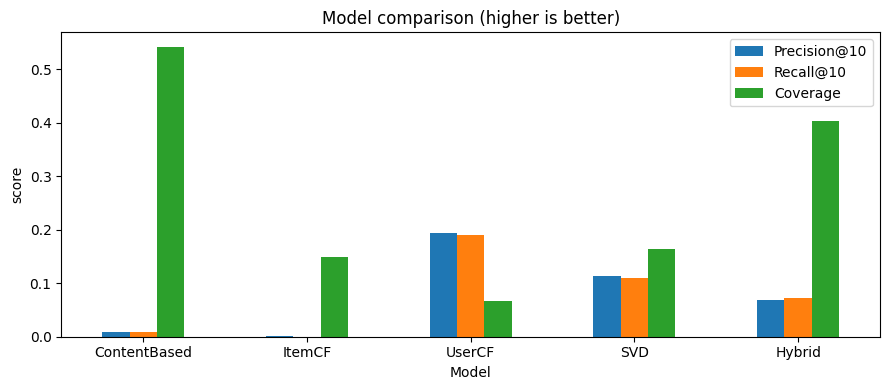

In [9]:
# visualize ranking quality
import matplotlib.pyplot as plt
ax = results[["Precision@10", "Recall@10", "Coverage"]].plot.bar(figsize=(9,4))
ax.set_title("Model comparison (higher is better)")
ax.set_ylabel("score"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 7. (Optional) Natural-language explanations
Needs `ANTHROPIC_API_KEY` or `OPENAI_API_KEY` in the environment. Falls back to a
templated sentence otherwise — so this cell always runs.

In [10]:
from src.llm_explainer import explain_recommendation
print(explain_recommendation(ds, USER, top_mid))

Recommended 'Pulp Fiction (1994)' because you rated Willy Wonka & the Chocolate Factory (1971), Go (1999), Star Wars: Episode V - The Empire Strikes Back (1980) highly -- it shares themes and audience with those.


## What next?
- Change knobs in `src/config.py` (latent factors, neighbors, hybrid weights) and re-run.
- Ask Claude Code to add an ALS model or a FastAPI endpoint — see `CLAUDE.md`.